# Task 06: House Price Prediction

## Objective
- Predict house prices based on property features such as size, number of bedrooms, and location. 
- The goal is to help buyers and sellers estimate property values accurately.

## Dataset
We are using the House Price Prediction Dataset (available on Kaggle). 
- Features include:
  - Size 
  - Number of bedrooms
  - Location
- Target variable: Price


In [12]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


## Step 1: Load the Dataset
We load the dataset using Pandas and check the first few rows to understand its structure.

In [13]:
df = pd.read_csv("Housing.csv")  
df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Step 2: Explore the Dataset
We check the basic statistics and missing values to understand the data better.


In [17]:
print(df.info())          # check column types and missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


In [18]:
print(df.isnull().sum())  # count missing values per column


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [19]:
df.describe()             # basic statistics

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## Step 3: Drop Rows with Missing Target
Remove any rows where the target variable `price` is missing, because we cannot train on missing targets.


In [21]:
# Drop rows with missing target (price)
df = df.dropna(subset=['price'])


## Step 4: Separate Features and Target
Separate the dataset into features (`X`) and target (`y`).  
- `X` contains all columns except `price`.  
- `y` contains the `price` column which we want to predict.


In [24]:
X = df.drop('price', axis=1)       #features
y = df['price']                    #target variable

## Step 5: Convert Categorical Variables
Convert categorical variables (like `location`) into numeric columns using **one-hot encoding**.  
- `drop_first=True` avoids the dummy variable trap.


In [25]:
X = pd.get_dummies(X, drop_first=True)
X = X.astype(int)
X.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


## Step 6: Handle Missing and Infinite Values
Replace infinite values with NaN and fill any remaining missing values with the **median** of each column.


In [16]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

## Step 7: Split Dataset
Split the data into training and testing sets:
- 80% for training
- 20% for testing


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Align columns (important if some categories appear only in train or test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


## Step 8: Train Linear Regression Model

In [27]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Step 9: Make predictions

In [28]:
y_pred = model.predict(X_test)
print(y_pred)

[5164653.90033967 7224722.29802167 3109863.24240338 4612075.3272256
 3294646.25725955 3532275.09556558 5611774.56836476 6368145.98732718
 2722856.95689985 2629405.61585782 9617039.5031558  2798087.30447888
 3171096.76847063 3394639.09125528 3681088.65424275 5263187.74621485
 3035963.47612384 4786122.8004005  4349551.9200572  3572362.09930451
 5774875.21395649 5886993.57919883 2730836.19518458 4727316.47323635
 5244847.527168   7555324.21605603 3220790.84680268 5191898.79934207
 8143726.91009785 3398814.09825035 6490693.05027925 3315105.9074781
 6708457.36761326 4201738.21071676 3557571.06735186 5836974.50478626
 4808660.67448475 4362878.73613261 3191242.95701508 4596554.93225238
 4566042.86048411 3517779.52374148 7205844.79365835 3983597.27861103
 3749338.70271056 4274731.09125895 6757442.10783741 4037320.43665851
 3769334.90397126 3417627.44377156 7268416.67644611 2802534.35431384
 4341750.61420452 4516422.15345642 3679997.65037847 2678959.06481152
 7498029.17782458 2920366.45493167 4

## Step 10: Evaluate Model
Calculate **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** to measure performance.

In [29]:
#Evaluate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))


Mean Absolute Error (MAE): 970043.4
Root Mean Squared Error (RMSE): 1324506.96


# Step 11: Visualize Actual vs Predicted Prices

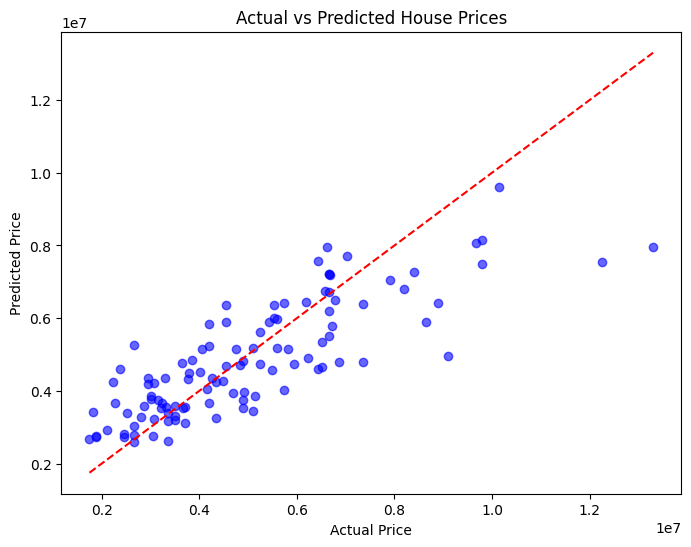

In [30]:
# Scatter plot of actual vs predicted prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


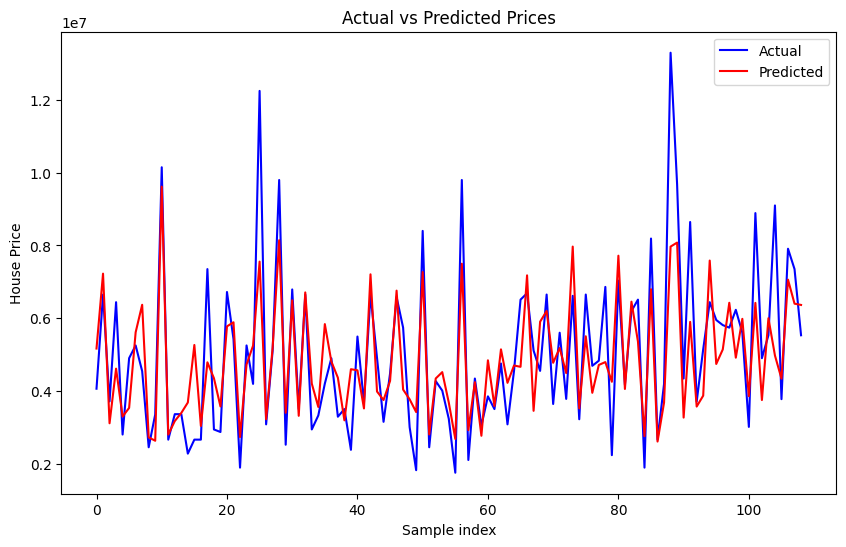

In [32]:
# Line plot of actual vs predicted prices
plt.figure(figsize=(10,6))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.xlabel("Sample index")
plt.ylabel("House Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()


# Step 11: Insights & Conclusion
- Linear Regression predicts house prices based on features like size, bedrooms, and location.  
- MAE and RMSE indicate average prediction error.  
- Features like location and square footage are most influential.  
- The model can be improved with more advanced regression or additional features.